In [15]:
import pandas as pd
import numpy as np
import json
import pandas_ta as ta
import os
from glob import glob

# =========================
# Configuration
# =========================
ATR_PERIOD    = 14
EMA_SHORT     = 21
EMA_LONG      = 50
HORIZON       = 48
SEQ_LEN       = 80
SWING_LEN     = 10
MIN_GAP       = 5

# Filtres trade — IDENTIQUES au backtest et au live bot
MIN_RR       = 0.55
MIN_N_ATR_SL = 1.5
MAX_N_ATR_SL = 5.5

DATA_DIR = './data'


# =========================
# TP/SL — fonction centralisée (identique live bot / backtest)
# =========================

def get_trade_levels(direction, entry_price, atr, swing_highs, swing_lows, n):
    if direction == 1:   # BUY
        sh_above = np.where(
            (~np.isnan(swing_highs[:n])) & (swing_highs[:n] > entry_price)
        )[0]
        sl_below = np.where(
            (~np.isnan(swing_lows[:n])) & (swing_lows[:n] < entry_price)
        )[0]
        if len(sh_above) == 0 or len(sl_below) == 0:
            return None, None

        tp_level     = swing_highs[sh_above[-1]]   # résistance structurelle
        sl_structure = swing_lows[sl_below[-1]]    # support structurel

        # ── SL : on prend le PLUS PROTECTEUR des deux
        # Si le support structural est trop proche (< 1.5 ATR), on recule
        # Si le support structural est trop loin (> 5.5 ATR), on resserre
        sl_atr_floor = entry_price - MAX_N_ATR_SL * atr   # plancher absolu
        sl_atr_ceil  = entry_price - MIN_N_ATR_SL * atr   # plafond minimum

        # Le SL final respecte la structure ET les limites ATR
        sl_level = np.clip(sl_structure, sl_atr_floor, sl_atr_ceil)

        # ── Vérification de cohérence : TP doit être au-dessus du SL
        if tp_level <= sl_level:
            return None, None

    else:   # SELL
        sl_below = np.where(
            (~np.isnan(swing_lows[:n])) & (swing_lows[:n] < entry_price)
        )[0]
        sh_above = np.where(
            (~np.isnan(swing_highs[:n])) & (swing_highs[:n] > entry_price)
        )[0]
        if len(sl_below) == 0 or len(sh_above) == 0:
            return None, None

        tp_level     = swing_lows[sl_below[-1]]
        sl_structure = swing_highs[sh_above[-1]]

        sl_atr_floor = entry_price + MIN_N_ATR_SL * atr
        sl_atr_ceil  = entry_price + MAX_N_ATR_SL * atr

        sl_level = np.clip(sl_structure, sl_atr_floor, sl_atr_ceil)

        if tp_level >= sl_level:
            return None, None

    return tp_level, sl_level


# =========================
# Détection des swings
# =========================

def find_swings(highs, lows, swing_len, min_gap=MIN_GAP):
    n           = len(highs)
    swing_highs = np.full(n, np.nan)
    swing_lows  = np.full(n, np.nan)

    shape   = (n - swing_len, swing_len)
    strides = highs.strides + highs.strides
    windows_h = np.lib.stride_tricks.as_strided(highs, shape=shape, strides=strides)
    windows_l = np.lib.stride_tricks.as_strided(lows,  shape=shape, strides=strides)

    raw_sh = np.full(n, np.nan)
    raw_sl = np.full(n, np.nan)

    for j in range(swing_len, n):
        w_idx = j - swing_len
        if highs[j] >= np.max(windows_h[w_idx]) - 1e-10:
            raw_sh[j] = highs[j]
        if lows[j]  <= np.min(windows_l[w_idx]) + 1e-10:
            raw_sl[j] = lows[j]

    sh_indices = np.where(~np.isnan(raw_sh))[0]
    sl_indices = np.where(~np.isnan(raw_sl))[0]

    def deduplicate(indices, values, keep='max', gap=min_gap):
        if len(indices) == 0:
            return indices
        result = [indices[0]]
        for idx in indices[1:]:
            if idx - result[-1] < gap:
                if keep == 'max' and values[idx] > values[result[-1]]:
                    result[-1] = idx
                elif keep == 'min' and values[idx] < values[result[-1]]:
                    result[-1] = idx
            else:
                result.append(idx)
        return np.array(result)

    sh_indices = deduplicate(sh_indices, highs, keep='max')
    sl_indices = deduplicate(sl_indices, lows,  keep='min')

    for idx in sh_indices:
        swing_highs[idx] = highs[idx]
    for idx in sl_indices:
        swing_lows[idx] = lows[idx]

    return swing_highs, swing_lows


# =========================
# Labeling — v6 : aligné sur le résultat réel du trade
# =========================

def market_structure_label(df, horizon, swing_len, min_swing_atr):
    highs  = df['high'].values
    lows   = df['low'].values
    closes = df['close'].values
    atrs   = df['atr'].values
    n      = len(closes)

    swing_highs, swing_lows = find_swings(highs, lows, swing_len, MIN_GAP)
    raw_labels = np.full(n, np.nan)

    for i in range(swing_len, n - horizon):
        past_sh = np.where(~np.isnan(swing_highs[:i]))[0]
        past_sl = np.where(~np.isnan(swing_lows[:i]))[0]
        if len(past_sh) == 0 or len(past_sl) == 0:
            continue

        last_sh      = swing_highs[past_sh[-1]]
        last_sl      = swing_lows[past_sl[-1]]
        current_atr  = atrs[i]

        if abs(last_sh - closes[i]) < min_swing_atr * current_atr:
            last_sh = np.nan
        if abs(closes[i] - last_sl) < min_swing_atr * current_atr:
            last_sl = np.nan
        if np.isnan(last_sh) and np.isnan(last_sl):
            continue

        buy_bar = sell_bar = np.inf
        for j in range(1, horizon + 1):
            if not np.isnan(last_sh) and highs[i + j]  > last_sh and buy_bar  == np.inf:
                buy_bar  = j
            if not np.isnan(last_sl) and lows[i + j]   < last_sl and sell_bar == np.inf:
                sell_bar = j
            if buy_bar < np.inf and sell_bar < np.inf:
                break

        if   buy_bar  < sell_bar: raw_labels[i] =  1
        elif sell_bar < buy_bar:  raw_labels[i] = -1

    return raw_labels


# =========================
# Features (identique v5)
# =========================

def build_feature_matrix(df):
    log_returns = np.log(df['close'] / df['close'].shift(1)).fillna(0).values
    hl_range    = ((df['high'] - df['low']) / df['close']).fillna(0).values

    atr_values = df['atr'].values
    assert np.all(atr_values[~np.isnan(atr_values)] > 0)
    atr_norm   = atr_values / df['close'].values

    hour     = df['datetime'].dt.hour.values
    dow      = df['datetime'].dt.dayofweek.values
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    dow_sin  = np.sin(2 * np.pi * dow  / 7)
    dow_cos  = np.cos(2 * np.pi * dow  / 7)

    ema_dist     = ((df['close'] - df['ema_short']) / df['close']).fillna(0)
    ema_spread   = ((df['ema_short'] - df['ema_long']) / df['close']).fillna(0).values
    ema_momentum = ema_dist.diff(5).fillna(0).values
    ema_dist     = ema_dist.values

    rsi       = df.ta.rsi(close=df['close'], length=ATR_PERIOD).fillna(50).values / 100
    macd      = (df['ema_short'] - df['ema_long']) / df['close']
    macd_hist = (macd - macd.ewm(span=9, adjust=False).mean()).fillna(0).values

    feats = [log_returns, hl_range, hour_sin, hour_cos, dow_sin, dow_cos,
             atr_norm, ema_dist, ema_spread, rsi, ema_momentum, macd_hist]
    scale_mask = [False, True, False, False, False, False, True,
                  False, False, False, False, False]

    if 'tick_volume' in df.columns:
        feats.insert(1, df['tick_volume'].values)
        scale_mask.insert(1, True)

    return np.column_stack(feats), scale_mask


# =========================
# Séquences & Scaling
# =========================

def create_sequences(data, targets, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len: i])
        y.append(targets[i])
    return np.array(X), np.array(y)


def apply_local_scaling(X_raw, scale_mask):
    X_scaled = np.copy(X_raw)
    for i in range(X_raw.shape[0]):
        for f in range(X_raw.shape[2]):
            if scale_mask[f]:
                seq  = X_raw[i, :, f]
                minv, maxv = np.min(seq), np.max(seq)
                X_scaled[i, :, f] = (seq - minv) / (maxv - minv) if maxv - minv > 1e-9 else 0.0
    return X_scaled


# =========================
# Pipeline
# =========================

all_train_X, all_train_y = [], []
all_val_X,   all_val_y   = [], []
all_test_X,  all_test_y  = [], []

json_files = glob(os.path.join(DATA_DIR, "*.json"))
print(f"Fichiers trouvés : {len(json_files)}")
print(f"Labeling v6 — aligné sur résultat réel du trade")
print(f"MIN_RR={MIN_RR} | SL [{MIN_N_ATR_SL}–{MAX_N_ATR_SL}] ATR | HORIZON={HORIZON}\n")

for file_path in json_files:
    pair_name = os.path.basename(file_path).replace('.json', '')
    print(f"\nProcessing {pair_name}...")

    with open(file_path, 'r') as f:
        df = pd.DataFrame(json.load(f))
    df['datetime'] = pd.to_datetime(df['end_time'], unit='s')
    df = df.sort_values('datetime').reset_index(drop=True)

    df.ta.atr(high=df['high'], low=df['low'], close=df['close'],
              length=ATR_PERIOD, append=True)
    atr_col = [c for c in df.columns if 'ATR' in c.upper()][0]
    df = df.rename(columns={atr_col: 'atr'})
    df['ema_short'] = df['close'].ewm(span=EMA_SHORT, adjust=False).mean()
    df['ema_long']  = df['close'].ewm(span=EMA_LONG,  adjust=False).mean()
    df = df.iloc[max(ATR_PERIOD, EMA_LONG):].reset_index(drop=True)
    df = df.dropna(subset=['atr', 'ema_short', 'ema_long']).reset_index(drop=True)

    # 6. Labeling sur le df complet et propre
    df['raw_label'] = market_structure_label(
        df,
        horizon       = HORIZON,
        swing_len     = SWING_LEN,
        min_swing_atr = MIN_SWING_ATR,
    )

    data_matrix, scale_mask = build_feature_matrix(df)
    X_p, y_p = create_sequences(data_matrix, df['raw_label'].values, SEQ_LEN)

    valid_mask = ~np.isnan(y_p)
    X_p = X_p[valid_mask]
    y_p = y_p[valid_mask]

    if len(X_p) == 0:
        print(f"  ⚠️  Aucun sample valide — paire ignorée")
        continue

    X_p_scaled = apply_local_scaling(X_p, scale_mask)

    label_map  = {1: 1, -1: 0}
    y_p_mapped = np.vectorize(label_map.get)(y_p.astype(int))

    n_buy  = (y_p_mapped == 1).sum()
    n_sell = (y_p_mapped == 0).sum()
    ratio  = n_buy / (n_sell + 1e-9)
    print(f"  BUY: {n_buy}, SELL: {n_sell}, ratio: {ratio:.2f}")
    if ratio > 2.0 or ratio < 0.5:
        print(f"  ⚠️  Déséquilibre sur {pair_name}")

    n         = len(X_p_scaled)
    train_idx = int(0.70 * n)
    val_idx   = int(0.85 * n)

    all_train_X.append(X_p_scaled[:train_idx])
    all_train_y.append(y_p_mapped[:train_idx])
    all_val_X.append(X_p_scaled[train_idx:val_idx])
    all_val_y.append(y_p_mapped[train_idx:val_idx])
    all_test_X.append(X_p_scaled[val_idx:])
    all_test_y.append(y_p_mapped[val_idx:])

# Concaténation & Shuffle
X_train_raw = np.concatenate(all_train_X, axis=0)
y_train_raw = np.concatenate(all_train_y, axis=0)
X_val  = np.concatenate(all_val_X,  axis=0)
y_val  = np.concatenate(all_val_y,  axis=0)
X_test = np.concatenate(all_test_X, axis=0)
y_test = np.concatenate(all_test_y, axis=0)

idx = np.arange(len(X_train_raw))
np.random.shuffle(idx)
X_train = X_train_raw[idx]
y_train = y_train_raw[idx]

print("\n--- Final Dataset ---")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"\nTrain → BUY: {(y_train==1).sum()}, SELL: {(y_train==0).sum()}")
print(f"Val   → BUY: {(y_val==1).sum()},   SELL: {(y_val==0).sum()}")
print(f"Test  → BUY: {(y_test==1).sum()},  SELL: {(y_test==0).sum()}")

Fichiers trouvés : 10
Labeling v6 — aligné sur résultat réel du trade
MIN_RR=0.55 | SL [1.5–5.5] ATR | HORIZON=48


Processing AUDJPY...
  BUY: 35514, SELL: 34568, ratio: 1.03

Processing CHFJPY...
  BUY: 36467, SELL: 35452, ratio: 1.03

Processing EURCHF...
  BUY: 33730, SELL: 37406, ratio: 0.90

Processing EURGBP...
  BUY: 35662, SELL: 35920, ratio: 0.99

Processing EURUSD...
  BUY: 36680, SELL: 35589, ratio: 1.03

Processing GBPCHF...
  BUY: 32913, SELL: 39467, ratio: 0.83

Processing GBPUSD...
  BUY: 34714, SELL: 35494, ratio: 0.98

Processing NZDJPY...
  BUY: 34694, SELL: 36397, ratio: 0.95

Processing USDJPY...
  BUY: 37825, SELL: 33468, ratio: 1.13

Processing XAUUSD...
  BUY: 36639, SELL: 34034, ratio: 1.08

--- Final Dataset ---
X_train: (498840, 80, 13), y_train: (498840,)
X_val:   (106894, 80, 13),   y_val:   (106894,)
X_test:  (106899, 80, 13),  y_test:  (106899,)

Train → BUY: 248815, SELL: 250025
Val   → BUY: 53653,   SELL: 53241
Test  → BUY: 52370,  SELL: 54529


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# X_train[:, -1, :] = features de la barre la plus récente de chaque séquence
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train[:, -1, :], y_train)
print(f"LR accuracy : {accuracy_score(y_val[:, -1, :] if False else y_val, lr.predict(X_val[:, -1, :])):.4f}")

LR accuracy : 0.6010


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class CTTS(nn.Module):
    """
    CNN + Transformer for Time Series (CTTS)
    With BatchNorm before GELU in MLP head
    """
    def __init__(self, 
                 input_dim, 
                 seq_len=80,
                 cnn_kernel_size=16,
                 cnn_stride=8,
                 d_model=128,
                 nhead=4,
                 num_layers=4,
                 dropout=0.3,
                 num_classes=3):
        super().__init__()
        
        # 1D CNN to project local windows into tokens
        self.conv = nn.Conv1d(in_channels=input_dim, 
                              out_channels=d_model, 
                              kernel_size=cnn_kernel_size, 
                              stride=cnn_stride)
        
        # Calculate number of tokens after convolution
        self.conv_out_len = (seq_len - cnn_kernel_size) // cnn_stride + 1
        
        # Learnable positional embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1, self.conv_out_len, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # LayerNorm and Dropout (standard for Transformer)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
        # MLP head with BatchNorm before GELU
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.BatchNorm1d(d_model // 2),      # BatchNorm added
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )
        
    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = x.permute(0, 2, 1)                # (batch, input_dim, seq_len)
        
        # CNN tokenization
        x = self.conv(x)                       # (batch, d_model, conv_out_len)
        x = x.permute(0, 2, 1)                 # (batch, conv_out_len, d_model)
        
        # Add positional embeddings
        x = x + self.pos_embed
        
        # Transformer
        x = self.transformer(x)                # (batch, conv_out_len, d_model)
        
        # Global average pooling
        x = x.mean(dim=1)                      # (batch, d_model)
        x = self.norm(x)
        x = self.dropout(x)
        
        # Classification head
        logits = self.head(x)                  # (batch, num_classes)
        return logits

In [17]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# =========================
# Device
# =========================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# =========================
# Tensors & DataLoaders
# =========================
batch_size = 512

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.LongTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=batch_size, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=batch_size, shuffle=False, pin_memory=True)

# =========================
# Modèle
# =========================
n_features = X_train.shape[2]

model = CTTS(
    input_dim       = n_features,
    seq_len         = 80,
    cnn_kernel_size = 16,
    cnn_stride      = 8,
    d_model         = 128,
    nhead           = 4,
    num_layers      = 4,
    dropout         = 0.3,
    num_classes     = 2,
).to(device)

# =========================
# Loss pondérée — FIX 1
# =========================
# Même sur un dataset quasi-équilibré, la weighted loss empêche le modèle
# de fuir vers la solution triviale (toujours prédire la classe majoritaire).
# Les poids sont calculés dynamiquement depuis y_train pour être reproductibles
# si le dataset change (nouvelles paires, nouveau MIN_RR, etc.)
n_sell = int((y_train == 0).sum())
n_buy  = int((y_train == 1).sum())
n_total = n_sell + n_buy


criterion = nn.CrossEntropyLoss()

# =========================
# Optimizer + Scheduler — FIX 2
# =========================
# Remplace ReduceLROnPlateau par CosineAnnealingLR.
#
# Pourquoi changer ?
# ReduceLROnPlateau réduit le LR quand val_acc stagne — ce qui est exactement
# ce qui se passe quand le modèle collapse. La réduction du LR aggrave le
# collapse au lieu de le corriger → boucle de mort.
#
# CosineAnnealingLR suit un planning fixe indépendant des performances :
# le LR descend de lr_max à eta_min en suivant une cosinus sur T_max epochs.
# L'early stopping peut couper le cycle à tout moment sans problème.
num_epochs = 100

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = num_epochs,   # durée complète du cycle cosinus
    eta_min = 1e-6,         # LR minimal en fin de cycle
)

# =========================
# Early Stopping
# =========================
# Découplé du scheduler — chacun joue son rôle indépendamment.
# patience=15 : si val_acc ne s'améliore pas pendant 15 epochs, on arrête.
# Le checkpoint est sauvegardé uniquement quand val_acc s'améliore.
patience        = 15
best_val_acc    = 0.0
epochs_no_improve = 0

# =========================
# Boucle d'entraînement
# =========================
for epoch in range(num_epochs):

    # --- Train ---
    model.train()
    train_loss = train_correct = train_total = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss    = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item() * batch_X.size(0)
        train_correct += (outputs.argmax(1) == batch_y).sum().item()
        train_total   += batch_y.size(0)

    train_loss /= train_total
    train_acc   = train_correct / train_total

    # --- Validation ---
    model.eval()
    val_loss = val_correct = val_total = 0
    all_probs = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs  = model(batch_X)
            loss     = criterion(outputs, batch_y)
            probs    = outputs.softmax(dim=1)

            val_loss    += loss.item() * batch_X.size(0)
            val_correct += (outputs.argmax(1) == batch_y).sum().item()
            val_total   += batch_y.size(0)
            all_probs.append(probs.cpu())

    val_loss /= val_total
    val_acc   = val_correct / val_total

    # --- Monitoring — FIX 3 ---
    # BUY%    : fraction de prédictions BUY → doit rester entre 30-70%
    #           Si → 0% ou 100% : le modèle collapse
    # Conf    : confiance moyenne → doit monter progressivement au-dessus de 0.55
    #           Si stagne à 0.50 : le modèle n'a pas de conviction
    # LR      : confirme que le cosinus descend correctement
    all_probs  = torch.cat(all_probs)
    buy_pct    = (all_probs.argmax(1) == 1).float().mean().item()
    mean_conf  = all_probs.max(1).values.mean().item()
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1:3d} | "
        f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
        f"BUY%: {buy_pct:.1%} | Conf: {mean_conf:.3f} | LR: {current_lr:.2e}"
    )

    # --- Scheduler step (epoch level, indépendant de val_acc) ---
    scheduler.step()

    # --- Checkpoint & Early Stopping ---
    if val_acc > best_val_acc:
        best_val_acc      = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_ctts_model.pth')
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

print(f"\nTraining finished. Best Validation Accuracy: {best_val_acc:.4f}")

# =========================
# Évaluation sur le test set
# =========================
model.load_state_dict(torch.load('best_ctts_model.pth', map_location=device))
model.eval()

test_preds, test_labels = [], []

with torch.no_grad():
    for batch_X, batch_y in DataLoader(
            TensorDataset(X_test_t, y_test_t), batch_size=batch_size):
        outputs = model(batch_X.to(device))
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_labels.extend(batch_y.numpy())

test_preds  = np.array(test_preds)
test_labels = np.array(test_labels)
test_acc    = (test_preds == test_labels).mean()

print(f"Test Accuracy: {test_acc:.4f}\n")

from sklearn.metrics import classification_report
print(classification_report(test_labels, test_preds, target_names=['SELL', 'BUY']))

# =========================
# Analyse seuils de confiance
# =========================
print("\n--- Analyse seuil de confiance (test set) ---")
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Coverage':>10} | {'N samples':>10} | {'BUY%':>8} | {'SELL%':>8}")
print("-" * 72)

with torch.no_grad():
    all_test_probs = []
    for batch_X, _ in DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size):
        probs = model(batch_X.to(device)).softmax(1)
        all_test_probs.append(probs.cpu())
all_test_probs = torch.cat(all_test_probs).numpy()

confidence  = all_test_probs.max(axis=1)
predictions = all_test_probs.argmax(axis=1)

for threshold in np.arange(0.50, 0.95, 0.05):
    mask = confidence >= threshold
    n    = mask.sum()
    if n == 0:
        print(f"{threshold:10.2f} | {'—':>10} | {'—':>10} | {0:>10} | {'—':>8} | {'—':>8}")
        continue
    acc      = (predictions[mask] == test_labels[mask]).mean()
    coverage = n / len(test_labels)
    buy_pct  = (predictions[mask] == 1).mean()
    sell_pct = (predictions[mask] == 0).mean()
    print(f"{threshold:10.2f} | {acc:10.4f} | {coverage:10.2%} | {n:10} | {buy_pct:8.2%} | {sell_pct:8.2%}")

Using device: cpu
Train: (498840, 80, 13), Val: (106894, 80, 13), Test: (106899, 80, 13)


C:\Users\larbi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1 | Train Loss: 0.6625, Acc: 0.5814 | Val Loss: 0.6413, Acc: 0.6021 | BUY%: 44.1% | Conf: 0.602 | LR: 3.00e-04
Epoch   2 | Train Loss: 0.6385, Acc: 0.6091 | Val Loss: 0.6375, Acc: 0.6026 | BUY%: 50.8% | Conf: 0.617 | LR: 3.00e-04
Epoch   3 | Train Loss: 0.6337, Acc: 0.6135 | Val Loss: 0.6350, Acc: 0.6059 | BUY%: 34.6% | Conf: 0.622 | LR: 3.00e-04
Epoch   4 | Train Loss: 0.6300, Acc: 0.6185 | Val Loss: 0.6324, Acc: 0.6114 | BUY%: 44.5% | Conf: 0.626 | LR: 2.99e-04
Epoch   5 | Train Loss: 0.6267, Acc: 0.6245 | Val Loss: 0.6296, Acc: 0.6155 | BUY%: 44.7% | Conf: 0.616 | LR: 2.99e-04
Epoch   6 | Train Loss: 0.6229, Acc: 0.6303 | Val Loss: 0.6329, Acc: 0.6157 | BUY%: 43.5% | Conf: 0.636 | LR: 2.98e-04
Epoch   7 | Train Loss: 0.6196, Acc: 0.6349 | Val Loss: 0.6327, Acc: 0.6192 | BUY%: 43.1% | Conf: 0.638 | LR: 2.97e-04
Epoch   8 | Train Loss: 0.6161, Acc: 0.6391 | Val Loss: 0.6381, Acc: 0.6149 | BUY%: 40.8% | Conf: 0.651 | LR: 2.96e-04
Epoch   9 | Train Loss: 0.6129, Acc: 0.6433 | Va

KeyboardInterrupt: 


KeyboardInterrupt



In [18]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('best_ctts_model.pth'))
model.eval()

test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == batch_y).sum().item()
        test_total += batch_y.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=['SELL', 'BUY']))

Test Accuracy: 0.6165
              precision    recall  f1-score   support

        SELL       0.61      0.68      0.64     54529
         BUY       0.62      0.55      0.58     52370

    accuracy                           0.62    106899
   macro avg       0.62      0.62      0.61    106899
weighted avg       0.62      0.62      0.61    106899



In [19]:
import numpy as np
import torch
import torch.nn as nn

# =========================
# Paramètres — à adapter
# =========================


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



# Adapte ces valeurs à ton architecture
# Initialize model
model = CTTS(
    input_dim=n_features,
    seq_len=80,
    cnn_kernel_size=16,
    cnn_stride=8,
    d_model=128,
    nhead=4,
    num_layers=4,
    dropout=0.3,
    num_classes=2
).to(DEVICE)

model.load_state_dict(torch.load('best_ctts_model.pth'))

model.to(DEVICE)
model.eval()

# =========================
# Inférence par batch
# =========================
print("Inférence...")
BATCH_SIZE = 512
all_probs = []

X_tensor = torch.FloatTensor(X_test)

with torch.no_grad():
    for i in range(0, len(X_tensor), BATCH_SIZE):
        batch = X_tensor[i : i + BATCH_SIZE].to(DEVICE)
        logits = model(batch)
        probs  = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs  = np.concatenate(all_probs, axis=0)   # (N, 2)
confidence = all_probs.max(axis=1)               # probabilité max par sample
preds      = all_probs.argmax(axis=1)            # classe prédite

# =========================
# Analyse par seuil de confiance
# =========================
print("\n--- Analyse seuil de confiance ---")
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Coverage':>10} | {'N samples':>10} | {'BUY%':>8} | {'SELL%':>8}")
print("-" * 70)

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

for t in thresholds:
    mask = confidence >= t
    n    = mask.sum()
    if n == 0:
        print(f"{t:>10.2f} | {'—':>10} | {'—':>10} | {0:>10} | {'—':>8} | {'—':>8}")
        continue

    acc      = (preds[mask] == y_test[mask]).mean()
    coverage = mask.mean()
    pct_buy  = (preds[mask] == 1).mean()
    pct_sell = (preds[mask] == 0).mean()

    print(f"{t:>10.2f} | {acc:>10.4f} | {coverage:>10.2%} | {n:>10} | {pct_buy:>8.2%} | {pct_sell:>8.2%}")

# =========================
# Distribution de confiance
# =========================
print("\n--- Distribution des scores de confiance ---")
bins = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.01]
for i in range(len(bins) - 1):
    lo, hi = bins[i], bins[i+1]
    mask   = (confidence >= lo) & (confidence < hi)
    n      = mask.sum()
    if n == 0:
        continue
    acc    = (preds[mask] == y_test[mask]).mean()
    print(f"  [{lo:.2f}, {hi:.2f}[ → {n:>7} samples ({mask.mean():.1%}), accuracy: {acc:.4f}")

# =========================
# Recap global
# =========================
global_acc = (preds == y_test).mean()
print(f"\nAccuracy globale (threshold=0.50) : {global_acc:.4f}")
print(f"Confidence moyenne                : {confidence.mean():.4f}")
print(f"Confidence médiane                : {np.median(confidence):.4f}")

Inférence...

--- Analyse seuil de confiance ---
 Threshold |   Accuracy |   Coverage |  N samples |     BUY% |    SELL%
----------------------------------------------------------------------
      0.50 |     0.6165 |    100.00% |     106899 |   43.23% |   56.77%
      0.55 |     0.6672 |     65.39% |      69901 |   46.70% |   53.30%
      0.60 |     0.7114 |     44.38% |      47446 |   54.52% |   45.48%
      0.65 |     0.7533 |     32.29% |      34522 |   61.54% |   38.46%
      0.70 |     0.7890 |     24.68% |      26383 |   66.53% |   33.47%
      0.75 |     0.8195 |     19.20% |      20526 |   70.22% |   29.78%
      0.80 |     0.8466 |     14.93% |      15959 |   72.81% |   27.19%
      0.85 |     0.8678 |     11.26% |      12037 |   75.46% |   24.54%
      0.90 |     0.8979 |      7.66% |       8189 |   78.12% |   21.88%

--- Distribution des scores de confiance ---
  [0.50, 0.55[ →   36998 samples (34.6%), accuracy: 0.5206
  [0.55, 0.60[ →   22455 samples (21.0%), accuracy: 0.5

<>:344: SyntaxWarning: invalid escape sequence '\$'
<>:356: SyntaxWarning: invalid escape sequence '\$'
<>:357: SyntaxWarning: invalid escape sequence '\$'
<>:344: SyntaxWarning: invalid escape sequence '\$'
<>:356: SyntaxWarning: invalid escape sequence '\$'
<>:357: SyntaxWarning: invalid escape sequence '\$'
C:\Users\larbi\AppData\Local\Temp\ipykernel_928\213863657.py:344: SyntaxWarning: invalid escape sequence '\$'
  return f'\${x:,.0f}'
C:\Users\larbi\AppData\Local\Temp\ipykernel_928\213863657.py:356: SyntaxWarning: invalid escape sequence '\$'
  f'Equity Curve — {len(all_df)} trades | PnL: \${pnl:,.0f} | '
C:\Users\larbi\AppData\Local\Temp\ipykernel_928\213863657.py:357: SyntaxWarning: invalid escape sequence '\$'
  f'WR: {winrate:.1%} | PF: {pf:.2f} | MaxDD: \${max_dd:,.0f}',


Chargement du modèle...
Modèle chargé. Device: cpu

Fichiers trouvés   : 8
Confidence seuil   : 0.85
One trade at a time: False
Risque / trade     : $800

Backtesting EURJPY...
  BUY: 1271 trades | WR: 61.9% | PnL: $139,027
  SELL: 386 trades | WR: 70.9% | PnL: $50,493
  Total: 1657 | TP: 597 | SL: 336 | Exp: 724 | WR: 64.0% | PnL: $189,520
Backtesting EURNZD...
  BUY: 936 trades | WR: 61.8% | PnL: $53,973
  SELL: 304 trades | WR: 70.6% | PnL: $40,061
  Total: 1240 | TP: 441 | SL: 253 | Exp: 546 | WR: 63.5% | PnL: $94,034
Backtesting GBPJPY...
  BUY: 1439 trades | WR: 65.9% | PnL: $211,504
  SELL: 409 trades | WR: 72.2% | PnL: $62,399
  Total: 1848 | TP: 667 | SL: 325 | Exp: 856 | WR: 67.2% | PnL: $273,903
Backtesting NZDCHF...
  BUY: 908 trades | WR: 58.8% | PnL: $59,822
  SELL: 358 trades | WR: 65.7% | PnL: $52,479
  Total: 1266 | TP: 413 | SL: 265 | Exp: 588 | WR: 60.9% | PnL: $112,301
Backtesting NZDUSD...
  BUY: 1400 trades | WR: 58.0% | PnL: $115,761
  SELL: 360 trades | WR: 63.3

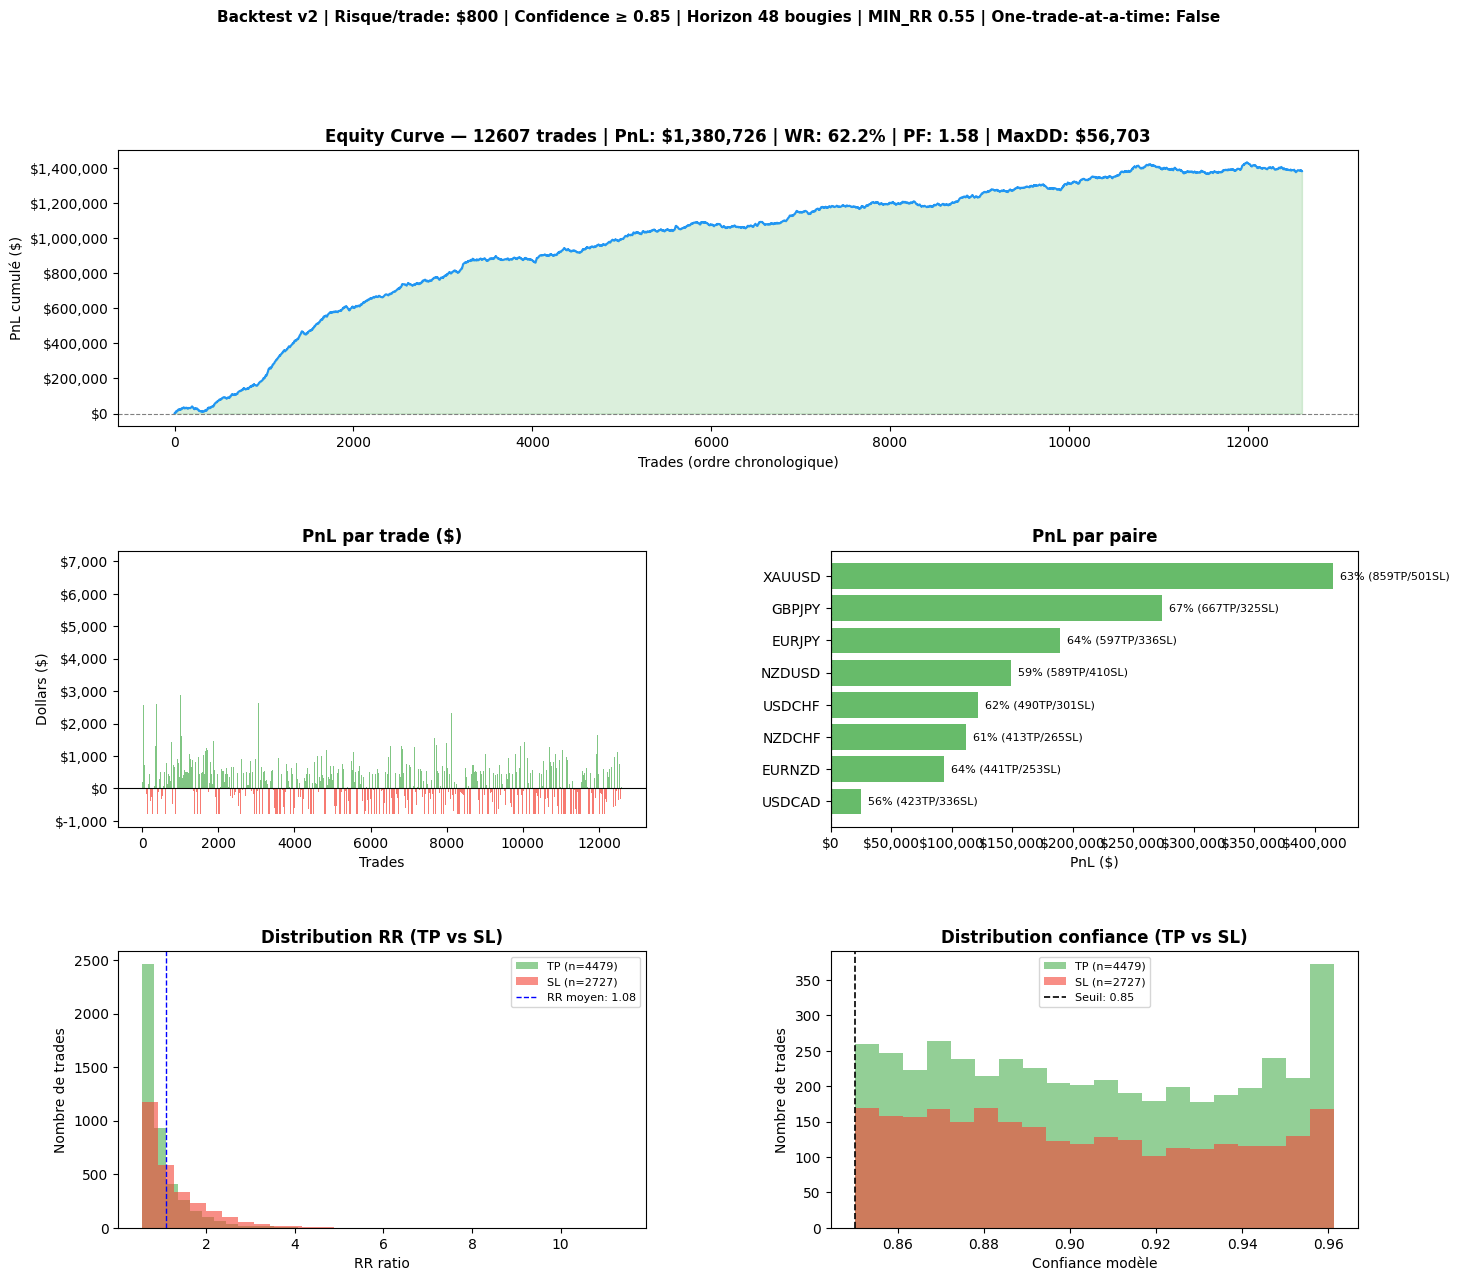


Sauvegardé : backtest_results.png


PermissionError: [Errno 13] Permission denied: 'backtest_trades.csv'

In [24]:
import numpy as np
import pandas as pd
import json
import torch
import torch.nn as nn
import pandas_ta as ta
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from glob import glob
import os

# =========================
# Paramètres
# =========================
MODEL_PATH = 'best_ctts_model.pth'
DATA_DIR   = './data-test'

# Seuil de confiance — basé sur l'analyse de calibration :
# 0.65 → accuracy 71.5%, coverage 40%   (recommandé pour stats robustes)
# 0.70 → accuracy 74.6%, coverage 24%   (moins de trades, meilleure qualité)
CONFIDENCE_THRESHOLD = 0.85

# Gestion du risque
RISK_DOLLARS = 800.0

# Filtres de qualité — IDENTIQUES au preprocessing v5 et au live bot
MIN_RR       = 0.55
MIN_N_ATR_SL = 1.5
MAX_N_ATR_SL = 50

# Indicateurs — IDENTIQUES au preprocessing
ATR_PERIOD = 14
EMA_SHORT  = 21
EMA_LONG   = 50
HORIZON    = 48
SEQ_LEN    = 80
SWING_LEN  = 10
MIN_GAP    = 5

# Gestion de position
# ── Une seule position ouverte à la fois par paire
# ── Pas de nouveau signal si un trade est encore en cours
ONE_TRADE_AT_A_TIME = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')




def create_sequences(data, seq_len):
    return np.array([data[i - seq_len: i] for i in range(seq_len, len(data))])


def price_move_to_dollars(price_move, risk, risk_dollars=RISK_DOLLARS):
    if risk <= 0:
        return 0.0
    return (price_move / risk) * risk_dollars


# =========================
# Chargement modèle
# =========================
print("Chargement du modèle...")
model = CTTS(
    input_dim       = 13,
    seq_len         = SEQ_LEN,
    cnn_kernel_size = 16,
    cnn_stride      = 8,
    d_model         = 128,
    nhead           = 4,
    num_layers      = 4,
    dropout         = 0.3,
    num_classes     = 2,
).to(DEVICE)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(
    checkpoint if isinstance(checkpoint, dict) and 'state_dict' not in checkpoint
    else checkpoint.get('state_dict', checkpoint)
)
model.eval()
print(f"Modèle chargé. Device: {DEVICE}\n")


# =========================
# Backtest
# =========================
all_trades     = []
pair_summaries = []

json_files = sorted(glob(os.path.join(DATA_DIR, "*.json")))
print(f"Fichiers trouvés   : {len(json_files)}")
print(f"Confidence seuil   : {CONFIDENCE_THRESHOLD}")
print(f"One trade at a time: {ONE_TRADE_AT_A_TIME}")
print(f"Risque / trade     : ${RISK_DOLLARS:,.0f}\n")

for file_path in json_files:
    pair_name = os.path.basename(file_path).replace('.json', '')
    print(f"{'=' * 50}")
    print(f"Backtesting {pair_name}...")

    # 1. Chargement & tri
    with open(file_path, 'r') as f:
        df = pd.DataFrame(json.load(f))
    df['datetime'] = pd.to_datetime(df['end_time'], unit='s')
    df = df.sort_values('datetime').reset_index(drop=True)

    # 2. Indicateurs
    df.ta.atr(high=df['high'], low=df['low'], close=df['close'],
              length=ATR_PERIOD, append=True)
    atr_col = [c for c in df.columns if 'ATR' in c.upper()][0]
    df = df.rename(columns={atr_col: 'atr'})
    df['ema_short'] = df['close'].ewm(span=EMA_SHORT, adjust=False).mean()
    df['ema_long']  = df['close'].ewm(span=EMA_LONG,  adjust=False).mean()
    df = df.iloc[max(ATR_PERIOD, EMA_LONG):].reset_index(drop=True)
    df = df.dropna(subset=['atr', 'ema_short', 'ema_long']).reset_index(drop=True)

    # 3. Swings sur toute la série
    swing_highs, swing_lows = find_swings(
        df['high'].values, df['low'].values, SWING_LEN
    )

    # 4. Features & séquences
    data_matrix, scale_mask = build_feature_matrix(df)
    X_raw    = create_sequences(data_matrix, SEQ_LEN)
    X_scaled = apply_local_scaling(X_raw, scale_mask)

    # 5. Inférence batch
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(X_scaled), 2048):
            batch = torch.FloatTensor(X_scaled[i:i + 2048]).to(DEVICE)
            all_probs.append(torch.softmax(model(batch), dim=1).cpu().numpy())
    all_probs  = np.concatenate(all_probs, axis=0)
    confidence = all_probs.max(axis=1)
    preds      = all_probs.argmax(axis=1)   # 0=SELL, 1=BUY

    trades = []

    # open_until_df_idx : index df jusqu'auquel un trade est en cours
    # Réinitialisé à -1 (aucun trade ouvert) au début de chaque paire
    open_until_df_idx = -1

    for seq_idx in range(len(X_scaled)):

        # --- Filtre confiance ---
        if confidence[seq_idx] < CONFIDENCE_THRESHOLD:
            continue

        direction = int(preds[seq_idx])
        df_idx    = seq_idx + SEQ_LEN

        if df_idx >= len(df) - HORIZON:
            continue

        # --- Filtre position (une trade à la fois) ---
        # Si ONE_TRADE_AT_A_TIME, on ignore les signaux tant que le trade
        # précédent n'est pas clôturé (TP, SL, ou horizon expiré)
        if ONE_TRADE_AT_A_TIME and df_idx <= open_until_df_idx:
            continue

        # --- Niveaux TP/SL ---
        entry_price   = df['close'].iloc[df_idx]
        atr_at_signal = df['atr'].iloc[df_idx]

        tp_level, sl_level = get_trade_levels(
            direction, entry_price, atr_at_signal,
            swing_highs, swing_lows, df_idx
        )

        if tp_level is None or sl_level is None:
            continue

        risk   = abs(entry_price - sl_level)
        reward = abs(tp_level    - entry_price)

        if risk <= 0 or reward <= 0:
            continue

        rr = reward / risk
        if rr < MIN_RR:
            continue

        # --- Simulation ---
        result     = 'expired'
        exit_price = None
        exit_bar   = HORIZON - 1

        future_highs  = df['high'].iloc[df_idx + 1: df_idx + 1 + HORIZON].values
        future_lows   = df['low'].iloc[df_idx + 1: df_idx + 1 + HORIZON].values
        future_closes = df['close'].iloc[df_idx + 1: df_idx + 1 + HORIZON].values

        for bar_offset, (fh, fl, fc) in enumerate(
                zip(future_highs, future_lows, future_closes)):
            if direction == 1:   # BUY
                if fl <= sl_level:
                    result, exit_price, exit_bar = 'sl', sl_level, bar_offset
                    break
                if fh >= tp_level:
                    result, exit_price, exit_bar = 'tp', tp_level, bar_offset
                    break
            else:                # SELL
                if fh >= sl_level:
                    result, exit_price, exit_bar = 'sl', sl_level, bar_offset
                    break
                if fl <= tp_level:
                    result, exit_price, exit_bar = 'tp', tp_level, bar_offset
                    break
        else:
            exit_price = future_closes[-1] if len(future_closes) > 0 else entry_price

        # Mise à jour de la fenêtre de blocage pour le trade suivant
        # Le trade est "ouvert" jusqu'à df_idx + 1 + exit_bar
        open_until_df_idx = df_idx + 1 + exit_bar

        # PnL
        if direction == 1:
            price_move = exit_price - entry_price
        else:
            price_move = entry_price - exit_price
        pnl_dollars = price_move_to_dollars(price_move, risk)

        trades.append({
            'pair':         pair_name,
            'datetime':     df['datetime'].iloc[df_idx],
            'direction':    'BUY' if direction == 1 else 'SELL',
            'confidence':   float(confidence[seq_idx]),
            'entry':        entry_price,
            'tp':           tp_level,
            'sl':           sl_level,
            'risk_dollars': RISK_DOLLARS,
            'rr_ratio':     rr,
            'result':       result,
            'pnl_dollars':  pnl_dollars,
            'exit_price':   exit_price,
            'exit_bar':     exit_bar,
        })

    all_trades.extend(trades)

    # --- Résumé par paire ---
    if not trades:
        print(f"  Aucun trade sur {pair_name}")
        continue

    tdf    = pd.DataFrame(trades)
    closed = tdf[tdf['result'].isin(['tp', 'sl'])]
    n_tp   = (tdf['result'] == 'tp').sum()
    n_sl   = (tdf['result'] == 'sl').sum()
    n_exp  = (tdf['result'] == 'expired').sum()
    n_tot  = len(tdf)
    pnl    = tdf['pnl_dollars'].sum()
    wr     = n_tp / max(n_tp + n_sl, 1)

    # Stats par direction
    for direction_label in ['BUY', 'SELL']:
        d = tdf[tdf['direction'] == direction_label]
        dc = d[d['result'].isin(['tp', 'sl'])]
        if len(dc) > 0:
            d_wr = (dc['result'] == 'tp').sum() / len(dc)
            print(f"  {direction_label}: {len(d)} trades | WR: {d_wr:.1%} | "
                  f"PnL: ${d['pnl_dollars'].sum():,.0f}")

    print(f"  Total: {n_tot} | TP: {n_tp} | SL: {n_sl} | Exp: {n_exp} | "
          f"WR: {wr:.1%} | PnL: ${pnl:,.0f}")

    pair_summaries.append({
        'pair':        pair_name,
        'signals':     n_tot,
        'tp':          n_tp,
        'sl':          n_sl,
        'expired':     n_exp,
        'winrate':     wr,
        'pnl_dollars': pnl,
        'avg_rr':      tdf['rr_ratio'].mean(),
    })


# =========================
# Résultats globaux
# =========================
if not all_trades:
    print("Aucun trade généré — vérifier CONFIDENCE_THRESHOLD et DATA_DIR")
    exit()

all_df = (
    pd.DataFrame(all_trades)
    .sort_values('datetime')
    .reset_index(drop=True)
)
closed_df = all_df[all_df['result'].isin(['tp', 'sl'])].copy()

print(f"\n{'=' * 55}")
print(f"RÉSULTATS GLOBAUX  (risque/trade : ${RISK_DOLLARS:,.0f})")
print(f"{'=' * 55}")
print(f"Total trades     : {len(all_df)}")
print(f"  TP             : {(all_df['result'] == 'tp').sum()}")
print(f"  SL             : {(all_df['result'] == 'sl').sum()}")
print(f"  Expired        : {(all_df['result'] == 'expired').sum()}")

if len(closed_df) > 0:
    n_tp    = (closed_df['result'] == 'tp').sum()
    winrate = n_tp / len(closed_df)
    pnl     = all_df['pnl_dollars'].sum()
    pnl_closed = closed_df['pnl_dollars'].sum()
    pnl_exp    = all_df[all_df['result'] == 'expired']['pnl_dollars'].sum()

    avg_win = closed_df[closed_df['pnl_dollars'] > 0]['pnl_dollars'].mean()
    avg_los = closed_df[closed_df['pnl_dollars'] < 0]['pnl_dollars'].mean()
    gross_p = closed_df[closed_df['pnl_dollars'] > 0]['pnl_dollars'].sum()
    gross_l = closed_df[closed_df['pnl_dollars'] < 0]['pnl_dollars'].sum()
    pf      = abs(gross_p / (gross_l + 1e-9))

    all_df['cumulative_pnl'] = all_df['pnl_dollars'].cumsum()
    max_dd = (all_df['cumulative_pnl'].cummax() - all_df['cumulative_pnl']).max()

    print(f"\nWinrate (TP/SL)  : {winrate:.1%}")
    print(f"PnL total        : ${pnl:,.0f}")
    print(f"  dont TP/SL     : ${pnl_closed:,.0f}")
    print(f"  dont Expired   : ${pnl_exp:,.0f}")
    print(f"Gain moyen       : ${avg_win:,.0f}")
    print(f"Perte moyenne    : ${avg_los:,.0f}")
    print(f"Profit Factor    : {pf:.2f}")
    print(f"R:R moyen        : {closed_df['rr_ratio'].mean():.2f}")
    print(f"Max Drawdown     : ${max_dd:,.0f}")

    # Stats par direction (global)
    print(f"\n--- Par direction ---")
    for d_label in ['BUY', 'SELL']:
        d  = all_df[all_df['direction'] == d_label]
        dc = closed_df[closed_df['direction'] == d_label]
        if len(dc) > 0:
            d_wr  = (dc['result'] == 'tp').sum() / len(dc)
            d_pnl = d['pnl_dollars'].sum()
            print(f"  {d_label}: {len(d)} trades | WR: {d_wr:.1%} | PnL: ${d_pnl:,.0f}")

    # =========================
    # Visualisation
    # =========================
    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    def dollar_fmt(x, _):
        return f'\${x:,.0f}'

    # ── Equity curve (pleine largeur)
    ax1 = fig.add_subplot(gs[0, :])
    cum = all_df['cumulative_pnl'].values
    ax1.plot(cum, color='#2196F3', linewidth=1.5)
    ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax1.fill_between(range(len(all_df)), cum, 0,
                     where=cum >= 0, alpha=0.2, color='#4CAF50')
    ax1.fill_between(range(len(all_df)), cum, 0,
                     where=cum  < 0, alpha=0.2, color='#F44336')
    ax1.set_title(
        f'Equity Curve — {len(all_df)} trades | PnL: \${pnl:,.0f} | '
        f'WR: {winrate:.1%} | PF: {pf:.2f} | MaxDD: \${max_dd:,.0f}',
        fontweight='bold'
    )
    ax1.set_xlabel('Trades (ordre chronologique)')
    ax1.set_ylabel('PnL cumulé ($)')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(dollar_fmt))

    # ── PnL par trade
    ax2 = fig.add_subplot(gs[1, 0])
    colors_pnl = ['#4CAF50' if p > 0 else '#F44336' for p in all_df['pnl_dollars']]
    ax2.bar(range(len(all_df)), all_df['pnl_dollars'].values,
            color=colors_pnl, alpha=0.7, width=1.0)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title('PnL par trade ($)', fontweight='bold')
    ax2.set_xlabel('Trades')
    ax2.set_ylabel('Dollars ($)')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(dollar_fmt))

    # ── PnL par paire
    ax3 = fig.add_subplot(gs[1, 1])
    sdf = pd.DataFrame(pair_summaries).sort_values('pnl_dollars')
    colors_p = ['#4CAF50' if p > 0 else '#F44336' for p in sdf['pnl_dollars']]
    ax3.barh(sdf['pair'], sdf['pnl_dollars'], color=colors_p, alpha=0.85)
    ax3.axvline(0, color='black', linewidth=0.8, linestyle='--')
    for i, row in sdf.reset_index().iterrows():
        ax3.text(
            row['pnl_dollars'], i,
            f"  {row['winrate']:.0%} ({row['tp']}TP/{row['sl']}SL)",
            va='center', fontsize=8
        )
    ax3.set_xlabel('PnL ($)')
    ax3.set_title('PnL par paire', fontweight='bold')
    ax3.xaxis.set_major_formatter(plt.FuncFormatter(dollar_fmt))

    # ── Distribution RR des trades gagnants vs perdants
    ax4 = fig.add_subplot(gs[2, 0])
    wins   = closed_df[closed_df['result'] == 'tp']['rr_ratio']
    losses = closed_df[closed_df['result'] == 'sl']['rr_ratio']
    ax4.hist(wins,   bins=30, alpha=0.6, color='#4CAF50', label=f'TP (n={len(wins)})')
    ax4.hist(losses, bins=30, alpha=0.6, color='#F44336', label=f'SL (n={len(losses)})')
    ax4.axvline(closed_df['rr_ratio'].mean(), color='blue',
                linestyle='--', linewidth=1, label=f'RR moyen: {closed_df["rr_ratio"].mean():.2f}')
    ax4.set_title('Distribution RR (TP vs SL)', fontweight='bold')
    ax4.set_xlabel('RR ratio')
    ax4.set_ylabel('Nombre de trades')
    ax4.legend(fontsize=8)

    # ── Distribution confiance
    ax5 = fig.add_subplot(gs[2, 1])
    conf_tp = closed_df[closed_df['result'] == 'tp']['confidence']
    conf_sl = closed_df[closed_df['result'] == 'sl']['confidence']
    ax5.hist(conf_tp, bins=20, alpha=0.6, color='#4CAF50', label=f'TP (n={len(conf_tp)})')
    ax5.hist(conf_sl, bins=20, alpha=0.6, color='#F44336', label=f'SL (n={len(conf_sl)})')
    ax5.axvline(CONFIDENCE_THRESHOLD, color='black',
                linestyle='--', linewidth=1.2, label=f'Seuil: {CONFIDENCE_THRESHOLD}')
    ax5.set_title('Distribution confiance (TP vs SL)', fontweight='bold')
    ax5.set_xlabel('Confiance modèle')
    ax5.set_ylabel('Nombre de trades')
    ax5.legend(fontsize=8)

    plt.suptitle(
        f'Backtest v2 | Risque/trade: ${RISK_DOLLARS:,.0f} | '
        f'Confidence ≥ {CONFIDENCE_THRESHOLD} | '
        f'Horizon {HORIZON} bougies | MIN_RR {MIN_RR} | '
        f'One-trade-at-a-time: {ONE_TRADE_AT_A_TIME}',
        fontsize=11, fontweight='bold'
    )

    plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSauvegardé : backtest_results.png")

    all_df.to_csv('backtest_trades.csv', index=False)
    print("Sauvegardé : backtest_trades.csv")